# 00 - Whisper vs Faster-Whisper na 40 prirodnih srpskih snimaka


## Cilj eksperimenta

U ovom notebook-u vrši se osnovno poređenje originalnog Whisper modela i Faster-Whisper implementacije na skupu od 40 prirodnih audio zapisa na srpskom jeziku, snimljenih od strane tri govornika. Audio zapisi su podeljeni u četiri grupe prema dužini: kratki, srednji, dugi i veoma dugi.

Za poređenje se koristi isti Whisper `base` model u tri konfiguracije: originalni Whisper, Faster-Whisper sa INT8 kvantizacijom i Faster-Whisper sa FLOAT32 načinom izračunavanja. Analiziraju se vreme transkripcije, Real-Time Factor (RTF), Word Error Rate (WER) i potrošnja RAM memorije.

Cilj je da se utvrdi u kojoj meri optimizovana Faster-Whisper implementacija može da smanji vreme izvršavanja i memorijske zahteve, uz očuvanje kvaliteta transkripcije na srpskom jeziku.


In [1]:
import os
import time
import wave
import gc
import re
from pathlib import Path

import psutil
import pandas as pd
import whisper
import jiwer
from faster_whisper import WhisperModel

# FFmpeg - putanja do ffmpeg.exe
os.environ["PATH"] += r";D:\anaconda\envs\whisper_test\Library\bin"

# Novi benchmark: 40 prirodnih srpskih snimaka / 3 govornika
AUDIO_FOLDER = Path(
    r"D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks"
)

# Rezultati ovog notebooka
PROJEKAT_FOLDER = AUDIO_FOLDER.parent.parent
REZULTATI_FOLDER = PROJEKAT_FOLDER / "rezultati" / "00_whisper_vs_faster_whisper"
REZULTATI_FOLDER.mkdir(parents=True, exist_ok=True)

def govornik_za_broj(i):
    if i in list(range(1, 5)) + list(range(11, 16)) + list(range(26, 29)) + [36]:
        return 1
    if i in list(range(5, 8)) + list(range(16, 21)) + list(range(29, 32)) + [37, 38]:
        return 2
    return 3

def grupa_duzine(i):
    if 1 <= i <= 10:
        return "kratki"
    if 11 <= i <= 25:
        return "srednji"
    if 26 <= i <= 35:
        return "dugi"
    return "veoma_dugi"

# Svih 40 novih prirodnih srpskih WAV fajlova
audio_fajlovi = [
    f"{i}govornik{govornik_za_broj(i)}.wav"
    for i in range(1, 41)
]

# Svi snimci su na srpskom
jezici_fajlova = ["sr"] * len(audio_fajlovi)

# Referentni tekstovi - moraju tačno odgovarati izgovorenim rečenicama
referentni_tekstovi_lista = ['Veštačka inteligencija omogućava računarima da rešavaju složene probleme i analiziraju velike količine podataka.', 'Automatsko prepoznavanje govora pretvara izgovorene reči u tekst koji računar može dalje da obrađuje.', 'Danas je veoma prijatan dan, pa smo odlučili da prošetamo kroz centar grada posle ručka.', 'Novi računari imaju brže procesore, više memorije i znatno bolje performanse nego prethodne generacije.', 'Mašinsko učenje koristi podatke kako bi model naučio da prepoznaje obrasce i donosi odgovarajuće odluke.', 'Sutra ujutru moram da završim nekoliko obaveza, a zatim planiram da se vidim sa prijateljima.', 'Kvalitet zvučnog zapisa može značajno da utiče na tačnost sistema za automatsko prepoznavanje govora.', 'Temperatura je tokom noći naglo pala, ali se očekuje da će sutra vreme ponovo biti toplije.', 'Neuronske mreže danas se koriste za obradu slike, teksta, zvuka i mnogih drugih vrsta podataka.', 'Dobar sistem mora istovremeno da bude dovoljno brz, precizan i pouzdan u različitim uslovima.', 'Savremeni sistemi za automatsko prepoznavanje govora koriste duboke neuronske mreže kako bi analizirali zvučni signal i pretvorili ga u tekst. Njihova tačnost zavisi od modela, kvaliteta snimka, jezika i karakteristika govornika.', 'Juče sam krenuo do grada nešto ranije nego obično. Na ulicama nije bilo mnogo ljudi, pa sam brzo završio sve obaveze. Nakon toga sam seo u obližnji kafić i sačekao prijatelja.', 'Whisper je model za automatsko prepoznavanje govora koji može da radi sa velikim brojem jezika. Faster-Whisper koristi optimizovanu implementaciju koja omogućava efikasnije izvršavanje i manju potrošnju računarskih resursa.', 'Kada razgovaramo u tihoj prostoriji, sistem uglavnom može veoma jasno da prepozna izgovorene reči. Međutim, saobraćaj, muzika, razgovor drugih ljudi i različiti izvori šuma mogu značajno da otežaju transkripciju.', 'Tokom razvoja softverske aplikacije programeri prvo analiziraju zahteve korisnika, zatim projektuju sistem i implementiraju potrebne funkcionalnosti. Nakon toga slede testiranje, ispravljanje grešaka i postavljanje aplikacije u produkciono okruženje.', 'Prošlog vikenda smo odlučili da provedemo dan u prirodi. Vreme je bilo sunčano i prijatno, pa smo poneli hranu i nekoliko stvari koje su nam bile potrebne. Vratili smo se kući tek predveče.', 'Veći modeli mašinskog učenja često mogu da postignu veću tačnost, ali zahtevaju više memorije i procesorske snage. Zbog toga najveći model nije uvek najbolji izbor za praktičnu primenu.', 'Brzina automatskog prepoznavanja govora posebno je važna kod aplikacija koje rade u realnom vremenu. Korisnik očekuje da sistem reaguje brzo i da se transkript pojavljuje bez primetnog kašnjenja.', 'Kada sam jutros uključio računar, prvo sam proverio elektronsku poštu i poruke. Posle toga sam otvorio projekat na kojem trenutno radim i nastavio implementaciju funkcionalnosti koju sam započeo prethodnog dana.', 'Srpski jezik sadrži glasove i karaktere koji se razlikuju od engleskog jezika. Zbog toga je interesantno analizirati koliko dobro isti model prepoznaje govor na različitim jezicima.', 'Kvantizacija omogućava da se neuronski model izvršava korišćenjem manje preciznih numeričkih formata. Na taj način moguće je smanjiti potrošnju memorije i ubrzati izvršavanje uz prihvatljivu promenu tačnosti.', 'Čovek tokom običnog razgovora često pravi kratke pauze, menja brzinu govora ili zastane kako bi razmislio. Sistem za prepoznavanje govora mora da bude dovoljno robustan da pravilno obradi takve situacije.', 'Danas postoji veliki broj aplikacija koje koriste veštačku inteligenciju. Ona se primenjuje u medicini, industriji, obrazovanju, saobraćaju, finansijama i mnogim svakodnevnim digitalnim servisima.', 'Kada se zvučnom signalu doda šum, neke reči postaju teže razumljive. Što je nivo šuma veći u odnosu na govor, sistemu je teže da napravi tačnu transkripciju celog snimka.', 'Pre nego što rezultate eksperimenta možemo pravilno da uporedimo, potrebno je koristiti iste ulazne podatke i jasno definisane metrike. Na taj način razlika u rezultatima može da se poveže sa promenom koju zapravo ispitujemo.', 'Automatsko prepoznavanje govora predstavlja oblast veštačke inteligencije koja se bavi pretvaranjem zvučnog signala u tekst. Savremeni sistemi koriste modele dubokog učenja koji mogu da analiziraju kompleksne karakteristike ljudskog govora. Njihove performanse mogu da zavise od jezika, kvaliteta mikrofona, prisustva pozadinskog šuma, brzine govora i karakteristika samog govornika. Zbog toga je prilikom evaluacije važno koristiti različite vrste zvučnih zapisa.', 'Jednog jutra krenuo sam automobilom prema gradu nešto ranije nego obično. Saobraćaj je u početku bio veoma slab, ali se približavanjem centru broj vozila postepeno povećavao. Dok sam čekao na semaforu, na radiju su govorili o vremenskoj prognozi za narednih nekoliko dana. Najavljeno je sunčano vreme, ali i mogućnost kratkotrajne kiše tokom vikenda. Kada sam stigao, parkirao sam automobil i nastavio pešice.', 'Whisper postoji u više veličina modela, od veoma malih do znatno većih modela. Manji modeli zahtevaju manje memorije i uglavnom omogućavaju bržu transkripciju, dok veći modeli mogu da pruže veću tačnost u zahtevnijim uslovima. Zbog toga izbor modela predstavlja kompromis između kvaliteta transkripcije i potrebnih računarskih resursa. Taj kompromis je posebno važan kada se sistem izvršava na običnom računaru bez snažne grafičke kartice.', 'Pozadinski šum predstavlja jedan od najčešćih problema kod sistema za automatsko prepoznavanje govora. U realnom okruženju mikrofon ne snima samo glas osobe već i zvuk automobila, ventilatora, drugih ljudi ili muzike. Ako je govor dovoljno snažan u odnosu na šum, transkripcija može ostati veoma dobra. Međutim, kada se odnos signala i šuma smanjuje, broj pogrešno prepoznatih reči uglavnom počinje da raste.', 'Kada razvijamo sistem koji treba da radi u realnom vremenu, nije dovoljno posmatrati samo njegovu tačnost. Potrebno je analizirati koliko vremena modelu treba da obradi određenu količinu zvuka. Ako obrada pet sekundi govora traje kraće od pet sekundi, sistem potencijalno može da prati govor bez stalnog povećavanja kašnjenja. Zbog toga su latencija i faktor realnog vremena veoma korisne metrike prilikom evaluacije ovakvih sistema.', 'Pre nekoliko dana organizovali smo malo okupljanje sa prijateljima. Dogovor je bio da se svi nađemo oko šest sati, ali je nekoliko ljudi kasnilo zbog saobraćaja. Dok smo ih čekali, razgovarali smo o poslu, putovanjima i planovima za naredne mesece. Kasnije smo naručili večeru i ostali zajedno nekoliko sati. Iako ništa posebno nije bilo planirano, veče je na kraju bilo veoma zanimljivo i prijatno.', 'Ljudski govor nije potpuno konstantan signal. Neko govori brzo, neko sporije, a pojedini govornici prave veoma duge pauze između rečenica. Razlikuju se i visina glasa, naglasak, način izgovora i jačina govora. Sistem koji postiže odlične rezultate kod jednog govornika zato ne mora nužno da postigne iste rezultate kod druge osobe. Korišćenje više govornika omogućava realniju procenu sposobnosti modela da generalizuje.', 'Voice Activity Detection koristi se za razlikovanje delova zvučnog zapisa u kojima postoji govor od delova u kojima se nalazi tišina. Ako snimak sadrži duge periode bez govora, njihovo uklanjanje može da smanji količinu podataka koju model mora da obradi. Međutim, algoritam mora pažljivo da odredi početak i kraj govora, jer previše agresivno uklanjanje može da odseče deo izgovorene reči i tako negativno utiče na transkripciju.', 'Beam search predstavlja jedan od načina pronalaženja verovatne sekvence reči tokom dekodiranja rezultata modela. Veća vrednost parametra omogućava razmatranje većeg broja mogućih kandidata, ali istovremeno može da poveća vreme potrebno za obradu. Zbog toga je korisno eksperimentalno proveriti da li povećanje beam size parametra zaista donosi značajno poboljšanje tačnosti i koliko dodatnih računarskih resursa zahteva.', 'Prilikom izvođenja eksperimenta veoma je važno menjati jednu karakteristiku sistema dok ostali uslovi ostaju isti. Ako istovremeno promenimo model, jezik, kvalitet zvuka i parametre dekodiranja, teško možemo da zaključimo zbog čega je rezultat postao bolji ili lošiji. Kontrolisani eksperimenti omogućavaju jasnije poređenje različitih konfiguracija i daju pouzdaniju osnovu za izvođenje zaključaka o ponašanju sistema.', 'Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu.', 'Kada govorimo o performansama modela za prepoznavanje govora, postoje dve različite stvari koje želimo da postignemo. Prva je što tačniji transkript, a druga što efikasnije izvršavanje. Veći model može bolje da prepozna komplikovane rečenice ili govor u težim uslovima, ali istovremeno može zahtevati mnogo više memorije i vremena. Manji model može biti nešto manje precizan, ali dovoljno brz da se koristi na običnom laptopu. Kvantizacija predstavlja još jedan način optimizacije jer omogućava korišćenje numeričkog formata manje preciznosti. Time se može smanjiti količina potrebne memorije i ubrzati obrada. Međutim, svaka optimizacija mora da bude eksperimentalno proverena. Nije dovoljno pokazati da je jedna konfiguracija brža. Potrebno je proveriti i da li je njena tačnost ostala prihvatljiva. Upravo zato se koriste metrike kao što su Word Error Rate, latencija i Real-Time Factor, koje omogućavaju da različite konfiguracije modela budu upoređene na objektivan način.', 'Prošle nedelje imao sam prilično ispunjen dan. Ujutru sam ustao ranije jer sam morao da završim nekoliko obaveza pre odlaska u grad. Posle doručka proverio sam poruke, pripremio stvari koje su mi bile potrebne i krenuo automobilom. Na putu je bilo više saobraćaja nego što sam očekivao, pa mi je trebalo skoro pola sata da stignem do centra. Prvo sam otišao do prodavnice, zatim do banke, a nakon toga sam se našao sa prijateljem kojeg nisam video nekoliko meseci. Razgovarali smo o poslu, putovanjima i planovima za narednu godinu. Posle ručka vreme se iznenada promenilo i počela je jaka kiša. Sačekali smo nekoliko minuta da se vreme malo smiri, a onda smo krenuli kući. Kada sam se vratio, nastavio sam da radim na računaru. Uveče sam završio preostale obaveze i odlučio da ostatak dana provedem odmarajući se.', 'Sistem koji obrađuje govor u realnom vremenu mora da rešava nešto drugačiji problem od sistema koji dobije kompletan audio zapis. Kod klasične transkripcije model može da dobije čitav snimak i zatim ga obradi. Kod realnog vremena zvuk neprestano pristiže, pa ga je potrebno podeliti na manje delove. Ako koristimo veoma kratke segmente, sistem može brzo da prikaže rezultat, ali model ima manje konteksta za pravilno prepoznavanje rečenice. Sa druge strane, ako koristimo duge segmente, model dobija više konteksta, ali korisnik mora duže da čeka na rezultat. Zbog toga izbor veličine segmenta predstavlja kompromis između latencije i kvaliteta transkripcije. Na primer, mogu se uporediti segmenti od dve, pet i deset sekundi. Za svaku konfiguraciju moguće je izmeriti vreme obrade, faktor realnog vremena i tačnost konačnog transkripta. Takav eksperiment omogućava da se utvrdi koja konfiguracija predstavlja najbolji kompromis za praktičan sistem.', 'Cilj eksperimentalne analize sistema za automatsko prepoznavanje govora jeste da se utvrdi kako različiti faktori utiču na njegov rad. Možemo menjati veličinu modela, nivo pozadinskog šuma, jezik govornika, parametre dekodiranja, način kvantizacije ili korišćenje algoritma za detekciju govora. Svaki eksperiment treba organizovati tako da možemo jasno da utvrdimo posledice određene promene. Rezultati se zatim mogu posmatrati kroz više metrika. Word Error Rate pokazuje koliko se prepoznati tekst razlikuje od tačnog referentnog transkripta. Latencija pokazuje koliko vremena je potrebno za obradu, dok Real-Time Factor povezuje vreme obrade sa trajanjem samog zvučnog zapisa. Potrošnja memorije je posebno značajna kada model treba da radi na uređajima sa ograničenim resursima. Kombinovanjem ovih rezultata možemo da pronađemo konfiguraciju koja ne mora biti najbolja prema svakoj pojedinačnoj metrici, ali predstavlja dobar kompromis između tačnosti, brzine i potrebnih računarskih resursa.']

referentni_tekstovi = {
    audio_fajlovi[i]: referentni_tekstovi_lista[i]
    for i in range(40)
}

print("Podešavanje je završeno.")
print(f"Audio folder: {AUDIO_FOLDER}")
print(f"Broj audio fajlova: {len(audio_fajlovi)}")
print(f"Rezultati: {REZULTATI_FOLDER}")

Podešavanje je završeno.
Audio folder: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
Broj audio fajlova: 40
Rezultati: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\00_whisper_vs_faster_whisper


In [2]:
def trajanje_wav(putanja):
    """Vraća trajanje WAV fajla u sekundama."""
    with wave.open(str(putanja), "rb") as f:
        frames = f.getnframes()
        rate = f.getframerate()
    return frames / float(rate)


def ram_mb():
    """Vraća trenutno zauzeće RAM-a procesa u MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)


def izmeri_vreme_i_ram(funkcija):
    """Meri vreme izvršavanja i promenu RAM memorije procesa."""
    gc.collect()
    ram_pre = ram_mb()
    pocetak = time.perf_counter()
    rezultat = funkcija()
    kraj = time.perf_counter()
    ram_posle = ram_mb()

    vreme = kraj - pocetak
    ram_promena = max(ram_posle - ram_pre, 0)
    return rezultat, vreme, ram_promena


def normalizuj_za_wer(tekst):
    """Lowercase + uklanjanje interpunkcije + sređivanje razmaka."""
    tekst = tekst.lower().strip()
    tekst = re.sub(r"[^\w\sčćžšđ]", " ", tekst, flags=re.UNICODE)
    tekst = re.sub(r"\s+", " ", tekst).strip()
    return tekst


def izracunaj_wer(referenca, hipoteza):
    return jiwer.wer(
        normalizuj_za_wer(referenca),
        normalizuj_za_wer(hipoteza)
    )

## Metodologija merenja

Za svaki audio zapis određuje se njegovo trajanje, nakon čega se ista ulazna datoteka transkribuje pomoću sve tri konfiguracije modela. Vreme izvršavanja meri se funkcijom `time.perf_counter()`, dok se promena zauzeća memorije procesa prati pomoću biblioteke `psutil`.

Kvalitet transkripcije procenjuje se pomoću metrike Word Error Rate (WER). Pre izračunavanja WER-a referentni i generisani tekst normalizuju se pretvaranjem u mala slova, uklanjanjem interpunkcije i sređivanjem razmaka. Na ovaj način poređenje je prvenstveno usmereno na greške u prepoznatim rečima, a ne na razlike u formatiranju teksta.

Pored vremena izvršavanja izračunava se i Real-Time Factor (RTF) kao odnos vremena obrade i trajanja audio zapisa. Vrednost RTF manja od 1 označava da se audio obrađuje brže od njegovog realnog trajanja.


In [3]:
print("PROVERA AUDIO FAJLOVA")
print("-" * 100)

nedostaju = []

for i, (fajl, jezik) in enumerate(zip(audio_fajlovi, jezici_fajlova), start=1):
    putanja = AUDIO_FOLDER / fajl
    govornik = govornik_za_broj(i)
    grupa = grupa_duzine(i)

    if putanja.exists():
        trajanje = trajanje_wav(putanja)
        print(
            f"{i:02d} | {fajl:<18} | govornik {govornik} | "
            f"{grupa:<10} | {jezik} | POSTOJI | {trajanje:.2f} s"
        )
    else:
        nedostaju.append(fajl)
        print(
            f"{i:02d} | {fajl:<18} | govornik {govornik} | "
            f"{grupa:<10} | {jezik} | NE POSTOJI"
        )

print("-" * 100)
print(f"Pronađeno: {40 - len(nedostaju)}/40")

if nedostaju:
    print("Nedostaju fajlovi:")
    for fajl in nedostaju:
        print(" -", fajl)
else:
    print("Sva 40 audio fajla su pronađena.")

PROVERA AUDIO FAJLOVA
----------------------------------------------------------------------------------------------------
01 | 1govornik1.wav     | govornik 1 | kratki     | sr | POSTOJI | 7.60 s
02 | 2govornik1.wav     | govornik 1 | kratki     | sr | POSTOJI | 6.78 s
03 | 3govornik1.wav     | govornik 1 | kratki     | sr | POSTOJI | 5.83 s
04 | 4govornik1.wav     | govornik 1 | kratki     | sr | POSTOJI | 7.29 s
05 | 5govornik2.wav     | govornik 2 | kratki     | sr | POSTOJI | 9.33 s
06 | 6govornik2.wav     | govornik 2 | kratki     | sr | POSTOJI | 7.89 s
07 | 7govornik2.wav     | govornik 2 | kratki     | sr | POSTOJI | 8.73 s
08 | 8govornik3.wav     | govornik 3 | kratki     | sr | POSTOJI | 5.21 s
09 | 9govornik3.wav     | govornik 3 | kratki     | sr | POSTOJI | 5.34 s
10 | 10govornik3.wav    | govornik 3 | kratki     | sr | POSTOJI | 5.60 s
11 | 11govornik1.wav    | govornik 1 | srednji    | sr | POSTOJI | 16.46 s
12 | 12govornik1.wav    | govornik 1 | srednji    | sr | POSTO

In [4]:
print("Učitavanje Original Whisper modela...")

model_orig = whisper.load_model("base", device="cpu")

print("Original Whisper je uspešno učitan.")

Učitavanje Original Whisper modela...
Original Whisper je uspešno učitan.


In [5]:
print("Učitavanje Faster-Whisper INT8 modela...")

model_fw_int8 = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

print("Faster-Whisper INT8 je uspešno učitan.")

Učitavanje Faster-Whisper INT8 modela...
Faster-Whisper INT8 je uspešno učitan.


In [6]:
print("Učitavanje Faster-Whisper FLOAT32 modela...")

model_fw_float32 = WhisperModel(
    "base",
    device="cpu",
    compute_type="float32"
)

print("Faster-Whisper FLOAT32 je uspešno učitan.")

Učitavanje Faster-Whisper FLOAT32 modela...
Faster-Whisper FLOAT32 je uspešno učitan.


## Poređenje Whisper konfiguracija

Svih 40 audio zapisa obrađuje se korišćenjem tri konfiguracije: originalnog Whisper `base` modela, Faster-Whisper `base` modela sa INT8 kvantizacijom i Faster-Whisper `base` modela sa FLOAT32 načinom izračunavanja.

Za svaki pojedinačni snimak čuvaju se trajanje audio zapisa, vreme transkripcije, promena RAM memorije, RTF i WER, kao i kompletni generisani transkripti. Dodatno se beleže govornik i grupa dužine snimka, što omogućava kasniju analizu uticaja trajanja audio zapisa i karakteristika govornika na performanse sistema.

Korišćenjem istih audio zapisa i istog `base` modela omogućeno je kontrolisano poređenje implementacija, pri čemu su glavne razlike način izvršavanja modela i numerička preciznost.


Kontrola parametara dekodiranja. Da bi poređenje različitih implementacija bilo metodološki korektno, parametri dekodiranja su eksplicitno usklađeni. Za sve konfiguracije korišćeni su beam_size=5, temperature=0.0, condition_on_previous_text=True i without_timestamps=False. Nije korišćen početni prompt (initial_prompt=None), dok je kod Faster-Whisper konfiguracija VAD eksplicitno isključen (vad_filter=False). Na taj način razlike u rezultatima ne potiču od različitih podrazumevanih strategija dekodiranja.


| Параметар | Original Whisper | FW FLOAT32 | FW INT8 |
|---|---|---|---|
| модел | Base | Base | Base |
| уређај | CPU | CPU | CPU |
| нумеричка прецизност | FP32 | FLOAT32 | INT8 |
| beam_size | 5 | 5 | 5 |
| temperature | 0.0 | 0.0 | 0.0 |
| condition_on_previous_text | True | True | True |
| without_timestamps | False | False | False |
| initial_prompt | None | None | None |
| VAD | — | False | False |

In [7]:
rezultati = []

for i, (fajl, jezik) in enumerate(zip(audio_fajlovi, jezici_fajlova), start=1):

    putanja = AUDIO_FOLDER / fajl

    if not putanja.exists():
        print(f"Fajl {fajl} ne postoji - preskačem.")
        continue

    print("\n" + "=" * 100)
    print(f"[{i:02d}/40] Obrada fajla: {fajl}")
    print(
        f"Govornik: {govornik_za_broj(i)} | "
        f"Grupa: {grupa_duzine(i)} | "
        f"Jezik: {jezik}"
    )

    trajanje = trajanje_wav(putanja)
    ref_tekst = referentni_tekstovi[fajl]

    # ============================================================
    # 1. ORIGINAL WHISPER
    # ============================================================
    def run_original():
        rezultat = model_orig.transcribe(
            str(putanja),
            language=jezik,
            task="transcribe",
            fp16=False,
            beam_size=5,
            temperature=0.0,
            condition_on_previous_text=True,
            without_timestamps=False,
            initial_prompt=None
        )
        return rezultat["text"].strip()

    tekst_orig, vreme_orig, ram_orig = izmeri_vreme_i_ram(
        run_original
    )
    wer_orig = izracunaj_wer(
        ref_tekst,
        tekst_orig
    )

    # ============================================================
    # 2. FASTER-WHISPER INT8
    # ============================================================
    def run_faster_int8():
        segments, info = model_fw_int8.transcribe(
            str(putanja),
            language=jezik,
            task="transcribe",
            beam_size=5,
            temperature=0.0,
            condition_on_previous_text=True,
            without_timestamps=False,
            initial_prompt=None,
            vad_filter=False
        )

        return " ".join(
            segment.text.strip()
            for segment in segments
        ).strip()

    tekst_fw_int8, vreme_fw_int8, ram_fw_int8 = izmeri_vreme_i_ram(
        run_faster_int8
    )
    wer_fw_int8 = izracunaj_wer(
        ref_tekst,
        tekst_fw_int8
    )

    # ============================================================
    # 3. FASTER-WHISPER FLOAT32
    # ============================================================
    def run_faster_float32():
        segments, info = model_fw_float32.transcribe(
            str(putanja),
            language=jezik,
            task="transcribe",
            beam_size=5,
            temperature=0.0,
            condition_on_previous_text=True,
            without_timestamps=False,
            initial_prompt=None,
            vad_filter=False
        )

        return " ".join(
            segment.text.strip()
            for segment in segments
        ).strip()

    tekst_fw_float32, vreme_fw_float32, ram_fw_float32 = izmeri_vreme_i_ram(
        run_faster_float32
    )
    wer_fw_float32 = izracunaj_wer(
        ref_tekst,
        tekst_fw_float32
    )

    # ============================================================
    # ČUVANJE REZULTATA
    # ============================================================
    rezultati.append({
        "Broj": i,
        "Audio": fajl.replace(".wav", ""),
        "Govornik": f"govornik{govornik_za_broj(i)}",
        "Grupa_duzine": grupa_duzine(i),
        "Jezik": jezik,
        "Trajanje [s]": round(trajanje, 2),

        "Vreme_Orig [s]": round(vreme_orig, 2),
        "RAM_Orig [MB]": round(ram_orig, 2),
        "RTF_Orig": round(vreme_orig / trajanje, 4),
        "WER_Orig": round(wer_orig, 4),

        "Vreme_FW_Int8 [s]": round(vreme_fw_int8, 2),
        "RAM_FW_Int8 [MB]": round(ram_fw_int8, 2),
        "RTF_FW_Int8": round(vreme_fw_int8 / trajanje, 4),
        "WER_FW_Int8": round(wer_fw_int8, 4),

        "Vreme_FW_F32 [s]": round(vreme_fw_float32, 2),
        "RAM_FW_F32 [MB]": round(ram_fw_float32, 2),
        "RTF_FW_F32": round(vreme_fw_float32 / trajanje, 4),
        "WER_FW_F32": round(wer_fw_float32, 4),

        "Referenca": ref_tekst,
        "Transkript_Orig": tekst_orig,
        "Transkript_FW_Int8": tekst_fw_int8,
        "Transkript_FW_F32": tekst_fw_float32
    })

    # ============================================================
    # ISPIS REZULTATA ZA TRENUTNI SNIMAK
    # ============================================================
    print(
        f"Original Whisper:       "
        f"{vreme_orig:.2f} s | WER {wer_orig * 100:.2f}%"
    )

    print(
        f"Faster-Whisper INT8:    "
        f"{vreme_fw_int8:.2f} s | WER {wer_fw_int8 * 100:.2f}%"
    )

    print(
        f"Faster-Whisper FLOAT32: "
        f"{vreme_fw_float32:.2f} s | WER {wer_fw_float32 * 100:.2f}%"
    )


[01/40] Obrada fajla: 1govornik1.wav
Govornik: 1 | Grupa: kratki | Jezik: sr
Original Whisper:       9.24 s | WER 30.77%
Faster-Whisper INT8:    2.09 s | WER 30.77%
Faster-Whisper FLOAT32: 2.93 s | WER 30.77%

[02/40] Obrada fajla: 2govornik1.wav
Govornik: 1 | Grupa: kratki | Jezik: sr
Original Whisper:       7.36 s | WER 28.57%
Faster-Whisper INT8:    1.58 s | WER 35.71%
Faster-Whisper FLOAT32: 2.31 s | WER 28.57%

[03/40] Obrada fajla: 3govornik1.wav
Govornik: 1 | Grupa: kratki | Jezik: sr
Original Whisper:       5.98 s | WER 53.33%
Faster-Whisper INT8:    1.51 s | WER 53.33%
Faster-Whisper FLOAT32: 2.45 s | WER 53.33%

[04/40] Obrada fajla: 4govornik1.wav
Govornik: 1 | Grupa: kratki | Jezik: sr
Original Whisper:       6.65 s | WER 50.00%
Faster-Whisper INT8:    1.73 s | WER 50.00%
Faster-Whisper FLOAT32: 2.30 s | WER 50.00%

[05/40] Obrada fajla: 5govornik2.wav
Govornik: 2 | Grupa: kratki | Jezik: sr
Original Whisper:       6.84 s | WER 26.67%
Faster-Whisper INT8:    1.63 s | WER 2

In [8]:
df = pd.DataFrame(rezultati)

print("SVA TESTIRANJA SU ZAVRŠENA.")

display(df)

SVA TESTIRANJA SU ZAVRŠENA.


,Broj,Audio,Govornik,Grupa_duzine,Jezik,Trajanje [s],Vreme_Orig [s],RAM_Orig [MB],RTF_Orig,WER_Orig,...,RTF_FW_Int8,WER_FW_Int8,Vreme_FW_F32 [s],RAM_FW_F32 [MB],RTF_FW_F32,WER_FW_F32,Referenca,Transkript_Orig,Transkript_FW_Int8,Transkript_FW_F32
0,1,1govornik1,govornik1,kratki,sr,7.60,9.24,0.00,1.2147,0.3077,...,0.2743,0.3077,2.93,258.29,0.3859,0.3077,Veštačka inteligencija omogućava računarima da...,Veštočka inteligencija omugućevaroču narima da...,Veštočka inteligencija omugućevaroču narima da...,Veštočka inteligencija omugućevaroču narima da...
1,2,2govornik1,govornik1,kratki,sr,6.78,7.36,0.00,1.0856,0.2857,...,0.2337,0.3571,2.31,0.21,0.3411,0.2857,Automatsko prepoznavanje govora pretvara izgov...,"Automacko prepoznavanje govora, pretvara izgov...","Automacko prepoznamenje govora, pretvara izgov...","Automacko prepoznavanje govora, pretvara izgov..."
2,3,3govornik1,govornik1,kratki,sr,5.83,5.98,0.00,1.0266,0.5333,...,0.2589,0.5333,2.45,0.11,0.4198,0.5333,"Danas je veoma prijatan dan, pa smo odlučili d...",Danas je veoma prijetan dan. Pasmo dlučili da ...,Danas je veoma prijetan dan. Pasmo dlučili da ...,Danas je veoma prijetan dan. Pasmo dlučili da ...
3,4,4govornik1,govornik1,kratki,sr,7.29,6.65,0.00,0.9125,0.5000,...,0.2372,0.5000,2.30,0.12,0.3152,0.5000,"Novi računari imaju brže procesore, više memor...","Novira čunari imaju brze procesore, više me mo...","Novira čunari imaju brze procesore, više me mo...","Novira čunari imaju brze procesore, više me mo..."
4,5,5govornik2,govornik2,kratki,sr,9.33,6.84,2.65,0.7329,0.2667,...,0.1745,0.2667,2.45,0.11,0.2630,0.2667,Mašinsko učenje koristi podatke kako bi model ...,Mašinsko učinje koristi podatke kako bi model ...,Mašinsko učinje koristi podatke kako bi model ...,Mašinsko učinje koristi podatke kako bi model ...
5,6,6govornik2,govornik2,kratki,sr,7.89,6.42,2.79,0.8127,0.2667,...,0.1947,0.3333,2.25,0.07,0.2856,0.2667,Sutra ujutru moram da završim nekoliko obaveza...,Sutre u jutru moram da završim nekoliko obavez...,Sutre u jutru moram da završim nekoliko obave ...,Sutre u jutru moram da završim nekoliko obavez...
6,7,7govornik2,govornik2,kratki,sr,8.73,7.50,0.48,0.8591,0.3571,...,0.2069,0.3571,2.60,1.04,0.2974,0.3571,Kvalitet zvučnog zapisa može značajno da utiče...,"Koalite zvučnog zapisa, može značenu da u tiče...","Koalite zvučnog zapisa, može značenu da u tiče...","Koalite zvučnog zapisa, može značenu da u tiče..."
7,8,8govornik3,govornik3,kratki,sr,5.21,6.03,0.00,1.1574,0.5625,...,0.2753,0.5625,2.06,0.09,0.3954,0.5625,"Temperatura je tokom noći naglo pala, ali se o...","Temperature tokom noći naglopala, ali se očeku...","Temperature tokom noći naglopala, ali se očeku...","Temperature tokom noći naglopala, ali se očeku..."
8,9,9govornik3,govornik3,kratki,sr,5.34,6.34,0.00,1.1867,0.6667,...,0.2854,0.6667,2.45,0.04,0.4582,0.6667,Neuronske mreže danas se koriste za obradu sli...,No hronskim reže danasi koristili za obradu sl...,No hronskim reže danasi koristili za obradu sl...,No hronskim reže danasi koristili za obradu sl...
9,10,10govornik3,govornik3,kratki,sr,5.60,5.84,0.10,1.0437,0.5714,...,0.2595,0.7143,2.08,0.17,0.3715,0.5714,Dobar sistem mora istovremeno da bude dovoljno...,Dobar sistemora i stovremeno da bude dovoljno ...,Dobar sistemora i stovremeno da bode dovoljno ...,Dobar sistemora i stovremeno da bude dovoljno ...


## Eksperiment 2 - Analiza vremena izvršavanja

U ovom delu porede se vremena potrebna za transkripciju svih 40 audio zapisa. Za svaki snimak izračunava se faktor ubrzanja Faster-Whisper INT8 i FLOAT32 konfiguracije u odnosu na originalni Whisper.

Faktor ubrzanja definiše se kao odnos vremena izvršavanja originalnog Whisper modela i vremena izvršavanja odgovarajuće Faster-Whisper konfiguracije. Vrednost veća od 1 označava da je Faster-Whisper brži od originalne implementacije.

Pored pojedinačnih rezultata prikazuju se i prosečne vrednosti, čime se dobija pregled ukupnog ponašanja modela na kompletnom benchmark skupu.


In [9]:
tabela1 = df[
    [
        "Audio",
        "Jezik",
        "Trajanje [s]",
        "Vreme_Orig [s]",
        "Vreme_FW_Int8 [s]",
        "Vreme_FW_F32 [s]"
    ]
].copy()

# Faktor ubrzanja INT8 u odnosu na Original Whisper
tabela1["Ubrzanje INT8"] = (
    tabela1["Vreme_Orig [s]"] /
    tabela1["Vreme_FW_Int8 [s]"]
).round(2)

# Faktor ubrzanja FLOAT32 u odnosu na Original Whisper
tabela1["Ubrzanje FLOAT32"] = (
    tabela1["Vreme_Orig [s]"] /
    tabela1["Vreme_FW_F32 [s]"]
).round(2)

display(tabela1)

,Audio,Jezik,Trajanje [s],Vreme_Orig [s],Vreme_FW_Int8 [s],Vreme_FW_F32 [s],Ubrzanje INT8,Ubrzanje FLOAT32
0,1govornik1,sr,7.60,9.24,2.09,2.93,4.42,3.15
1,2govornik1,sr,6.78,7.36,1.58,2.31,4.66,3.19
2,3govornik1,sr,5.83,5.98,1.51,2.45,3.96,2.44
3,4govornik1,sr,7.29,6.65,1.73,2.30,3.84,2.89
4,5govornik2,sr,9.33,6.84,1.63,2.45,4.20,2.79
5,6govornik2,sr,7.89,6.42,1.54,2.25,4.17,2.85
6,7govornik2,sr,8.73,7.50,1.81,2.60,4.14,2.88
7,8govornik3,sr,5.21,6.03,1.44,2.06,4.19,2.93
8,9govornik3,sr,5.34,6.34,1.52,2.45,4.17,2.59
9,10govornik3,sr,5.60,5.84,1.45,2.08,4.03,2.81


In [10]:
numericke_kolone = [
    "Trajanje [s]",
    "Vreme_Orig [s]",
    "Vreme_FW_Int8 [s]",
    "Vreme_FW_F32 [s]",
    "Ubrzanje INT8",
    "Ubrzanje FLOAT32"
]

prosek = tabela1[numericke_kolone].mean()

red_proseka = {
    "Audio": "PROSEK",
    "Jezik": "sr"
}

for kolona in numericke_kolone:
    red_proseka[kolona] = round(prosek[kolona], 2)

tabela1_sa_prosekom = pd.concat(
    [
        tabela1,
        pd.DataFrame([red_proseka])
    ],
    ignore_index=True
)

display(tabela1_sa_prosekom)

,Audio,Jezik,Trajanje [s],Vreme_Orig [s],Vreme_FW_Int8 [s],Vreme_FW_F32 [s],Ubrzanje INT8,Ubrzanje FLOAT32
0,1govornik1,sr,7.60,9.24,2.09,2.93,4.42,3.15
1,2govornik1,sr,6.78,7.36,1.58,2.31,4.66,3.19
2,3govornik1,sr,5.83,5.98,1.51,2.45,3.96,2.44
3,4govornik1,sr,7.29,6.65,1.73,2.30,3.84,2.89
4,5govornik2,sr,9.33,6.84,1.63,2.45,4.20,2.79
5,6govornik2,sr,7.89,6.42,1.54,2.25,4.17,2.85
6,7govornik2,sr,8.73,7.50,1.81,2.60,4.14,2.88
7,8govornik3,sr,5.21,6.03,1.44,2.06,4.19,2.93
8,9govornik3,sr,5.34,6.34,1.52,2.45,4.17,2.59
9,10govornik3,sr,5.60,5.84,1.45,2.08,4.03,2.81


In [11]:
tabela1_sa_prosekom.to_csv(
    REZULTATI_FOLDER / "tabela1_uporedna_analiza_vremena.csv",
    index=False,
    encoding="utf-8-sig"
)

df.to_csv(
    REZULTATI_FOLDER / "svi_rezultati_whisper.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabela 1 i kompletni rezultati su uspešno sačuvani.")

Tabela 1 i kompletni rezultati su uspešno sačuvani.


## Eksperiment 3 - Poređenje performansi


In [12]:
tabela3 = pd.DataFrame({
    "Audio": df["Audio"],
    "Jezik": df["Jezik"],
    "Trajanje [s]": df["Trajanje [s]"],
    "Whisper [s]": df["Vreme_Orig [s]"],
    "Faster-Whisper [s]": df["Vreme_FW_Int8 [s]"]
})

tabela3["Ubrzanje"] = (
    tabela3["Whisper [s]"] /
    tabela3["Faster-Whisper [s]"]
).round(2)

display(tabela3)

,Audio,Jezik,Trajanje [s],Whisper [s],Faster-Whisper [s],Ubrzanje
0,1govornik1,sr,7.60,9.24,2.09,4.42
1,2govornik1,sr,6.78,7.36,1.58,4.66
2,3govornik1,sr,5.83,5.98,1.51,3.96
3,4govornik1,sr,7.29,6.65,1.73,3.84
4,5govornik2,sr,9.33,6.84,1.63,4.20
5,6govornik2,sr,7.89,6.42,1.54,4.17
6,7govornik2,sr,8.73,7.50,1.81,4.14
7,8govornik3,sr,5.21,6.03,1.44,4.19
8,9govornik3,sr,5.34,6.34,1.52,4.17
9,10govornik3,sr,5.60,5.84,1.45,4.03


In [13]:
prosecno_ukupno_ubrzanje = (
    tabela3["Whisper [s]"].sum() /
    tabela3["Faster-Whisper [s]"].sum()
)

prosecno_ubrzanje_po_zapisima = tabela3["Ubrzanje"].mean()

print(
    f"Ukupno ubrzanje Faster-Whisper INT8: "
    f"{prosecno_ukupno_ubrzanje:.2f}x"
)

print(
        f"Prosečan faktor ubrzanja po audio zapisima: "
    f"{prosecno_ubrzanje_po_zapisima:.2f}x"
)

Ukupno ubrzanje Faster-Whisper INT8: 4.73x
Prosečan faktor ubrzanja po audio zapisima: 4.91x


In [14]:
tabela3.to_csv(
    REZULTATI_FOLDER / "tabela3_poredjenje_whisper_faster.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabela 3 je uspešno sačuvana.")

Tabela 3 je uspešno sačuvana.


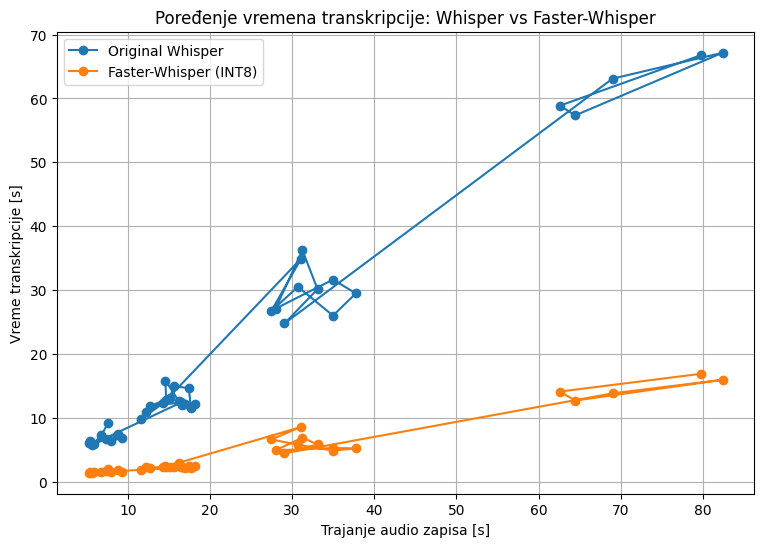

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    tabela3["Trajanje [s]"],
    tabela3["Whisper [s]"],
    marker="o",
    label="Original Whisper"
)

plt.plot(
    tabela3["Trajanje [s]"],
    tabela3["Faster-Whisper [s]"],
    marker="o",
    label="Faster-Whisper (INT8)"
)

plt.xlabel("Trajanje audio zapisa [s]")
plt.ylabel("Vreme transkripcije [s]")
plt.title("Poređenje vremena transkripcije: Whisper vs Faster-Whisper")
plt.legend()
plt.grid(True)

plt.savefig(
    REZULTATI_FOLDER / "grafik_poredjenje_whisper_faster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Komentar rezultata

Poređenje vremena transkripcije omogućava direktnu procenu računarske efikasnosti originalnog Whisper modela i Faster-Whisper INT8 implementacije. Faktor ubrzanja veći od 1 označava prednost Faster-Whisper implementacije, dok ukupni faktor ubrzanja, izračunat na osnovu ukupnog vremena obrade svih snimaka, daje reprezentativniju procenu performansi kompletnog benchmark skupa.

Grafik prikazuje odnos između trajanja audio zapisa i vremena potrebnog za njegovu transkripciju. Očekuje se rast vremena obrade sa povećanjem trajanja snimka, dok razmak između dve krive pokazuje razliku u efikasnosti implementacija.

Originalni Whisper koristi PyTorch implementaciju, dok Faster-Whisper koristi CTranslate2 optimizovano izvršavanje. Zbog toga ovo poređenje pokazuje koliko promena implementacije i korišćenje INT8 konfiguracije mogu da utiču na brzinu izvršavanja istog `base` modela na CPU-u.

Rezultate vremena izvršavanja ne treba posmatrati izolovano, već zajedno sa WER i memorijskim rezultatima, jer praktično korisna optimizacija treba da obezbedi ubrzanje bez neprihvatljivog smanjenja kvaliteta transkripcije.


## Eksperiment 4 - RAM potrošnja


In [16]:
import gc
import os
import psutil

proces = psutil.Process(os.getpid())

def ram_mb():
    return proces.memory_info().rss / (1024 * 1024)

print(f"Trenutna RAM potrošnja procesa: {ram_mb():.2f} MB")

Trenutna RAM potrošnja procesa: 1264.34 MB


In [17]:
# Oslobađanje prethodno učitanih modela
try:
    del model_orig
except NameError:
    pass

try:
    del model_fw_int8
except NameError:
    pass

try:
    del model_fw_float32
except NameError:
    pass

gc.collect()

ram_pre_whisper = ram_mb()

model_whisper_ram = whisper.load_model("base", device="cpu")

ram_posle_whisper = ram_mb()

ram_whisper = ram_posle_whisper - ram_pre_whisper

print(f"RAM pre učitavanja:   {ram_pre_whisper:.2f} MB")
print(f"RAM posle učitavanja: {ram_posle_whisper:.2f} MB")
print(f"Promena RAM-a:        {ram_whisper:.2f} MB")

RAM pre učitavanja:   758.21 MB
RAM posle učitavanja: 863.03 MB
Promena RAM-a:        104.81 MB


In [18]:
# Oslobađanje Original Whisper modela
del model_whisper_ram
gc.collect()

ram_pre_faster = ram_mb()

model_faster_ram = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

ram_posle_faster = ram_mb()

ram_faster = ram_posle_faster - ram_pre_faster

print(f"RAM pre učitavanja:   {ram_pre_faster:.2f} MB")
print(f"RAM posle učitavanja: {ram_posle_faster:.2f} MB")
print(f"Promena RAM-a:        {ram_faster:.2f} MB")

RAM pre učitavanja:   863.05 MB
RAM posle učitavanja: 953.88 MB
Promena RAM-a:        90.83 MB


In [19]:
tabela4 = pd.DataFrame({
    "Model": [
        "Original Whisper",
        "Faster-Whisper INT8"
    ],
    "RAM [MB]": [
        round(ram_whisper, 2),
        round(ram_faster, 2)
    ]
})

display(tabela4)

,Model,RAM [MB]
0,Original Whisper,104.81
1,Faster-Whisper INT8,90.83


In [20]:
tabela4.to_csv(
    REZULTATI_FOLDER / "tabela4_ram_potrosnja.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabela 4 je uspešno sačuvana.")

Tabela 4 je uspešno sačuvana.


## Komentar rezultata - RAM potrošnja

U ovom eksperimentu poredi se dodatno zauzeće RAM memorije prilikom učitavanja originalnog Whisper `base` modela i Faster-Whisper `base` modela u INT8 konfiguraciji. Pre svakog merenja prethodno učitani model se uklanja iz memorije i poziva se garbage collector kako bi se smanjio uticaj prethodnog merenja.

Razlika između memorije procesa pre i posle učitavanja modela koristi se kao procena dodatne RAM memorije potrebne za njegovo učitavanje. INT8 reprezentacija koristi numerički format manje preciznosti, pa može omogućiti smanjenje memorijskih zahteva u odnosu na standardnu implementaciju.

Dobijene vrednosti predstavljaju potrošnju u konkretnom eksperimentalnom okruženju i ne treba ih tumačiti kao apsolutnu veličinu samog modela. Na rezultat mogu uticati Python runtime, prethodno učitane biblioteke, način upravljanja memorijom i operativni sistem. Zbog toga je najvažnije relativno poređenje konfiguracija izvršenih u istom okruženju.


## Eksperiment 5 - Detaljna analiza kvaliteta transkripcije na reprezentativnom snimku

In [21]:
from jiwer import wer

# Jedan reprezentativan veoma dug prirodni srpski snimak
test_audio_naziv = "36govornik1.wav"
test_audio = AUDIO_FOLDER / test_audio_naziv
referenca = referentni_tekstovi[test_audio_naziv]

print("Test audio:")
print(test_audio)

print("\nReferentni tekst:")
print(referenca)

Test audio:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks\36govornik1.wav

Referentni tekst:
Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti

In [22]:
model_whisper_wer = whisper.load_model("base", device="cpu")

rezultat_whisper = model_whisper_wer.transcribe(
    str(test_audio),
    language="sr",
    fp16=False
)

tekst_whisper = rezultat_whisper["text"].strip()

print("ORIGINAL WHISPER:")
print(tekst_whisper)

ORIGINAL WHISPER:
Savrimini sistemi za otomacko prepoznavanja govara imaju velik broje praktičnih primjenu. Mogu se koristiti za otomacko pravnje transkripeta, sastanka, generisanje titlova, glasov neasistente, pretregu multimelijalno-k sadrgeja i pobošanje pristopačnosti digitanih sistema. Ipak kvalitet njihovo grada zavisio od velikog broje faktor. Gorojnici imivra razečite glasovje, akcente i brzi negovor. Do snimci mogu nasati koristijenje mračiti mikrofoni i u razečitim prostorijem. Dolatnim problem predstavlja pozdinskišum, sistem koji veoma dobro radi u tihu i prostoriji, nemora da postivnijesti rezultat na ulici i utomu bilu. Zbog toga, evalulacije sistema nebi trevalo da bude zastomana na samo jednom zvušnom zapisu. Potranome korisiti više govornika, razečite tuži ne snimaka i razečite ustlje. Poretaršnosti zreskrijpcije važnje analizirati vremi izvršavanja. Potrošnju memoria isposobno sistema da obradio zvuku dovoljno brazo za praktičnu primenu.


In [23]:
model_faster_wer = WhisperModel(
    "base",
    device="cpu",
    compute_type="int8"
)

segments, info = model_faster_wer.transcribe(
    str(test_audio),
    language="sr"
)

tekst_faster = " ".join(
    segment.text.strip()
    for segment in segments
).strip()

print("FASTER-WHISPER:")
print(tekst_faster)

FASTER-WHISPER:
Savrimini sistemi za otomacko prepoznavenja govara imaju velik broje praktičnih primena. Mogu se koristiti za otomacko pravnje transkripeta, sastanka, generisanje titlova, glasov neasistente, pretregu multimelijalno-k sadrgeja i pobošanje pristopačnosti digitalnih sistema. Ipak kvalitet njihovo grada zavisi od velikog broje faktor. Gornici imivra, razečite glasovje, akcente i brzine govora. Dok snimci mogu nasati koristijenjem račiti mikrofoni i u razečitim prostorijem. Dolatnim problem predstavlja pozadinski šum, sistem koji veoma dobro radi u tihvi prostoriji, nemora da postivni isti rezultat na ulici i utomu bilo. Zbog toga, evalulacije sistema nebi trevalo da bude zastomana na samo jednom zvušnom zapisu. Potranome korisiti više govornika, razečite tuži ne snimaka i razečite ustlje. Poretaršnosti zreskripsije važne analizirati vremi izvršavanja. Potrošnju memoria isposobno sistema da obradio je zvuku dovoljno brazo za praktičnu primenu.


In [24]:
wer_whisper = izracunaj_wer(
    referenca,
    tekst_whisper
)

wer_faster = izracunaj_wer(
    referenca,
    tekst_faster
)

tabela5 = pd.DataFrame({
    "Model": [
        "Original Whisper",
        "Faster-Whisper INT8"
    ],
    "WER": [
        round(wer_whisper, 4),
        round(wer_faster, 4)
    ],
    "WER [%]": [
        round(wer_whisper * 100, 2),
        round(wer_faster * 100, 2)
    ]
})

display(tabela5)

,Model,WER,WER [%]
0,Original Whisper,0.5846,58.46
1,Faster-Whisper INT8,0.5154,51.54


In [25]:
print("=" * 80)
print("REFERENTNI TEKST")
print("=" * 80)
print(referenca)

print("\n" + "=" * 80)
print("ORIGINAL WHISPER")
print("=" * 80)
print(tekst_whisper)

print("\n" + "=" * 80)
print("FASTER-WHISPER")
print("=" * 80)
print(tekst_faster)

REFERENTNI TEKST
Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu.

O

In [26]:
tabela5.to_csv(
    REZULTATI_FOLDER / "tabela5_wer.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabela 5 je uspešno sačuvana.")

Tabela 5 je uspešno sačuvana.


## Komentar rezultata - kvalitet transkripcije

Kvalitet transkripcije poredi se pomoću metrike Word Error Rate (WER), koja uzima u obzir zamene, brisanja i umetanja reči u odnosu na referentni transkript. Niža WER vrednost označava precizniju transkripciju, dok WER jednak 0 predstavlja potpuno podudaranje sa referentnim tekstom nakon primenjene normalizacije.

Za detaljno poređenje izabran je veoma dug prirodni srpski audio zapis `36govornik1.wav`. Originalni Whisper i Faster-Whisper INT8 obrađuju isti snimak korišćenjem `base` modela, nakon čega se njihovi transkripti porede sa identičnim referentnim tekstom.

Ovaj pojedinačni primer omogućava detaljan pregled konkretnih razlika između generisanih transkripata, ali ga ne treba posmatrati kao procenu ukupne tačnosti modela. Reprezentativnija procena kvaliteta nalazi se u rezultatima obrade svih 40 audio zapisa, gde je WER izračunat za svaki snimak.

Zajedničkim posmatranjem WER-a, vremena izvršavanja, RTF-a i memorijske potrošnje moguće je proceniti da li Faster-Whisper INT8 pruža povoljniji kompromis između tačnosti i računarske efikasnosti u odnosu na originalni Whisper.
